# Airfoil Self-Noise Exploratory Data Analysis

NASA data set, obtained from a series of aerodynamic and acoustic tests of two and three-dimensional airfoil blade sections conducted in an anechoic wind tunnel.

Brooks, T., Pope, D., & Marcolini, M. (1989). Airfoil Self-Noise [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5VW2C.

In [1]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
# fetch dataset 
dataset = fetch_ucirepo(id=291) 
  
# data (as pandas dataframes) 
X = dataset.data.features 
y = dataset.data.targets 

In [3]:
# variable information 
print(dataset.variables)

print("\n--- First 5 rows of the dataset ---")
print(X.head())

print("\n--- Statistics of the dataset ---")
print(X.describe())

                                  name     role        type demographic  \
0                            frequency  Feature     Integer        None   
1                         attack-angle  Feature      Binary        None   
2                         chord-length  Feature  Continuous        None   
3                 free-stream-velocity  Feature  Continuous        None   
4  suction-side-displacement-thickness  Feature  Continuous        None   
5                scaled-sound-pressure   Target  Continuous        None   

  description units missing_values  
0        None    Hz             no  
1        None   deg             no  
2        None     m             no  
3        None   m/s             no  
4        None     m             no  
5        None    dB             no  

--- First 5 rows of the dataset ---
   frequency  attack-angle  chord-length  free-stream-velocity  \
0        800           0.0        0.3048                  71.3   
1       1000           0.0        0.3048      

## Visual and Dataframe Exploration

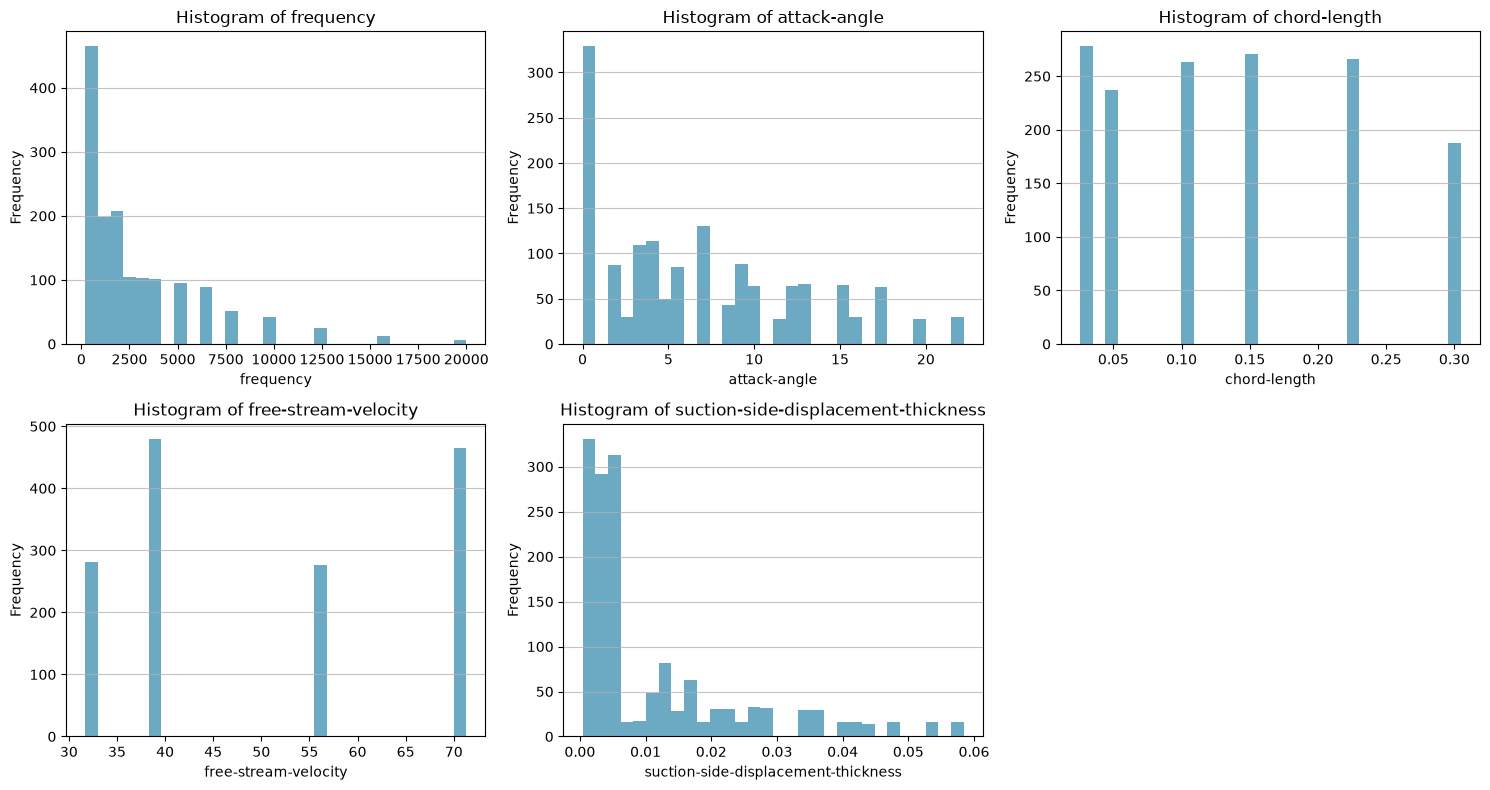

In [4]:
# Check data distribution to see if it is normal or not
def plot_histograms(X):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
    axes = axes.flatten()

    for i, feature in enumerate(X.columns):
        axes[i].hist(X[feature], bins=30, alpha=0.7, color='#2E86AB')
        axes[i].set_title(f'Histogram of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(axis='y', alpha=0.75)

    for j in range(len(X.columns), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_histograms(X)

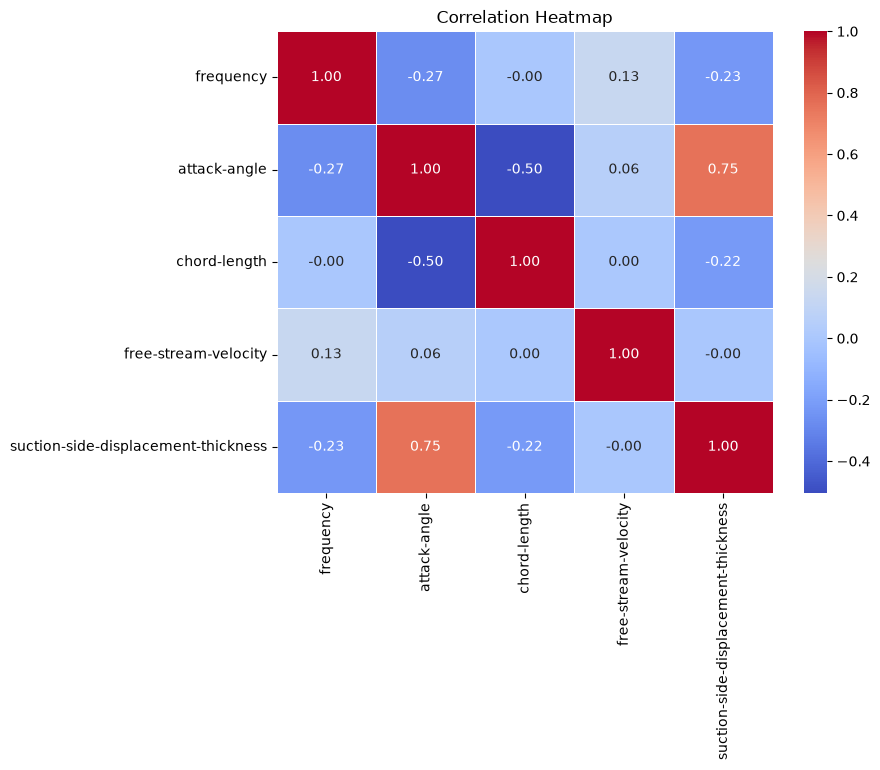

In [5]:
# Check correlation between features using a simple heatmap
matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

There's a 0.75 correlation between *attack-angle* and *suction-side-displacement-thickness*. Since the rest of the matrix features low or negative correlation, we can keep all features for the Symbolic Regression model.

## Statistic Analysis & Target Transformation

In [6]:
target = y.squeeze()

print(f"Original Skewness: {target.skew():.3f}")
print(f"Original Kurtosis: {target.kurt():.3f}")

# Outliers via IQR
Q1, Q3 = target.quantile(0.25), target.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = target[(target < lower) | (target > upper)]

print(f"\nOutliers (IQR method): {len(outliers)} out of {len(target)} ({100*len(outliers)/len(target):.1f}%)")

Original Skewness: -0.419
Original Kurtosis: -0.314

Outliers (IQR method): 4 out of 1503 (0.3%)


In [7]:
y_log = np.log1p(target)  # Log transformation
y_sqrt = np.sqrt(target)  # Square root transformation
y_box_cox, _ = stats.boxcox(target + 1)  # Box-Cox transformation

print(f"Skewness after log transformation: {y_log.skew():.3f}")
print(f"Skewness after square root transformation: {y_sqrt.skew():.3f}")
print(f"Skewness after Box-Cox transformation: {pd.Series(y_box_cox).skew():.3f}")

Skewness after log transformation: -0.547
Skewness after square root transformation: -0.483
Skewness after Box-Cox transformation: -0.044


Clearly, the Box-Cox transformation provides the best skewness. However, during the evaluation of the model, we found that the log transformation provided better results. Therefore, we will use the log transformation for our final model.

## Group Division & Safe Data Splitting
We group by physical experiment identifiers to avoid data leakage before applying any models.

In [8]:
from sklearn.model_selection import GroupShuffleSplit

df = X.copy()
# We will use the Log transformed target based on our pipeline benchmarks
df['scaled-sound-pressure'] = y_log.values

# Grouping by physical experiment identifiers
group_cols = ["attack-angle", "chord-length", "free-stream-velocity"]
df["group_id"] = df[group_cols].astype(str).agg("-".join, axis=1)

print(f"Unique groups: {df['group_id'].nunique()}")
print(f"Average rows per group: {len(df) / df['group_id'].nunique():.1f}")

# Split by group to avoid data leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["group_id"]))

train_df = df.iloc[train_idx].drop(columns="group_id")
test_df = df.iloc[test_idx].drop(columns="group_id")

# Safety check for leakage
train_groups = set(df.iloc[train_idx]["group_id"])
test_groups = set(df.iloc[test_idx]["group_id"])
assert len(train_groups & test_groups) == 0, "Data leakage detected!"

print(f"\nTrain: {len(train_df)} rows, Test: {len(test_df)} rows. No overlap detected.")

Unique groups: 106
Average rows per group: 14.2

Train: 1188 rows, Test: 315 rows. No overlap detected.


## Symbolic Regression Training

In [9]:
from pysr import PySRRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import os

os.makedirs("results", exist_ok=True)

TARGET = "scaled_sound_pressure"
FEATURES = ["frequency", "attack_angle", "chord_length",
            "free_stream_velocity", "suction_side_displacement_thickness"]

# Rename columns to replace hyphens with underscores (PySR requirement)
rename_dict = {col: col.replace("-", "_") for col in train_df.columns}
train_df_renamed = train_df.rename(columns=rename_dict)
test_df_renamed = test_df.rename(columns=rename_dict)

X_train, y_train = train_df_renamed[FEATURES].values, train_df_renamed[TARGET].values
X_test, y_test_log = test_df_renamed[FEATURES].values, test_df_renamed[TARGET].values

# Define the PySR model
model = PySRRegressor(
    niterations=500,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log", "sqrt", "square", "exp"],
    populations=30,
    maxsize=30,
    model_selection="best",
    loss="loss(x, y) = (x - y)^2",
    random_state=42,
    parallelism='serial',
    deterministic=True
)

# Train the model
model.fit(X_train, y_train, variable_names=FEATURES)

print("\n=== Selected Equation ===")
print(model.sympy())

# Test evaluation: Inverse transform to evaluate on the original decibel scale
y_pred_log = model.predict(X_test)
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_log)

rmse = root_mean_squared_error(y_test_orig, y_pred_orig)
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"\nTest RMSE: {rmse:.3f} dB")
print(f"Test MAE:  {mae:.3f} dB")
print(f"Test R²:   {r2:.3f}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


f:\repos\SymbolicRegressionAirfoil\.venv\Lib\site-packages\pysr\sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
f:\repos\SymbolicRegressionAirfoil\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 3.800e+04
Progress: 208 / 15000 total iterations (1.387%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.182e-03  0.000e+00  y = 4.8326
3           2.873e-03  5.107e-02  y = 4.8437 - suction_side_displacement_thickness
5           2.871e-03  2.315e-04  y = (4.7952 - suction_side_displacement_thickness) * 1.010...
                                      1
6           2.849e-03  7.750e-03  y = exp((suction_side_displacement_thickness * -0.28402) +...
                                       1.5781)
7           2.846e-03  1.118e-03  y = exp(exp((suction_side_displacement_thickness * -0.1816...
                                      8) + 0.4565))
8           2.731e-03  4.130e-02  y = (3.1188 - suction_side_displacement_thickness) + sqrt(...
            

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.182e-03  0.000e+00  y = 4.8326
3           2.873e-03  5.107e-02  y = 4.8437 - suction_side_displacement_thickness
4           2.869e-03  1.429e-03  y = 5.8438 - exp(suction_side_displacement_thickness)
5           2.663e-03  7.453e-02  y = 4.8534 - (frequency * 7.0974e-06)
6           2.628e-03  1.312e-02  y = 4.876 - (sqrt(frequency) * 0.00091046)
7           1.973e-03  2.868e-01  y = 4.8533 - (frequency * (suction_side_displacement_thick...
                                      ness * 0.00091301))
8           1.590e-03  2.160e-01  y = ((frequency * sqrt(suction_side_displacement_thickness...
                                      )) * -0.00017487) - -4.8698
9           1.506e-03  5.386e-02  y = 4.8571 - (chord_length * ((suction_side_displacement_t...
                                      hickness * 0.0087366) * frequency))
10    

## Equation Readability and Manual Checks

In [10]:
from IPython.display import display, Math
raw_latex = model.latex() 

print("=== Equation in LaTeX format ===")
display(Math(raw_latex))

=== Equation in LaTeX format ===


<IPython.core.display.Math object>

In [11]:
# Manual testing comparing actual vs predicted on original scale
total_indices = 5
random_indices = np.random.choice(len(y_test_orig), total_indices, replace=False)

y_test_sample = y_test_orig[random_indices]
y_pred_sample = y_pred_orig[random_indices]

for i in range(len(random_indices)):
    diff = abs(y_test_sample[i] - y_pred_sample[i])
    print(f"Actual: {y_test_sample[i]:.2f} dB  |  Predicted: {y_pred_sample[i]:.2f} dB  |  Error: {diff:.2f} dB")

Actual: 126.05 dB  |  Predicted: 130.56 dB  |  Error: 4.51 dB
Actual: 129.40 dB  |  Predicted: 126.38 dB  |  Error: 3.01 dB
Actual: 121.43 dB  |  Predicted: 125.03 dB  |  Error: 3.59 dB
Actual: 125.63 dB  |  Predicted: 121.65 dB  |  Error: 3.98 dB
Actual: 133.77 dB  |  Predicted: 126.64 dB  |  Error: 7.13 dB
